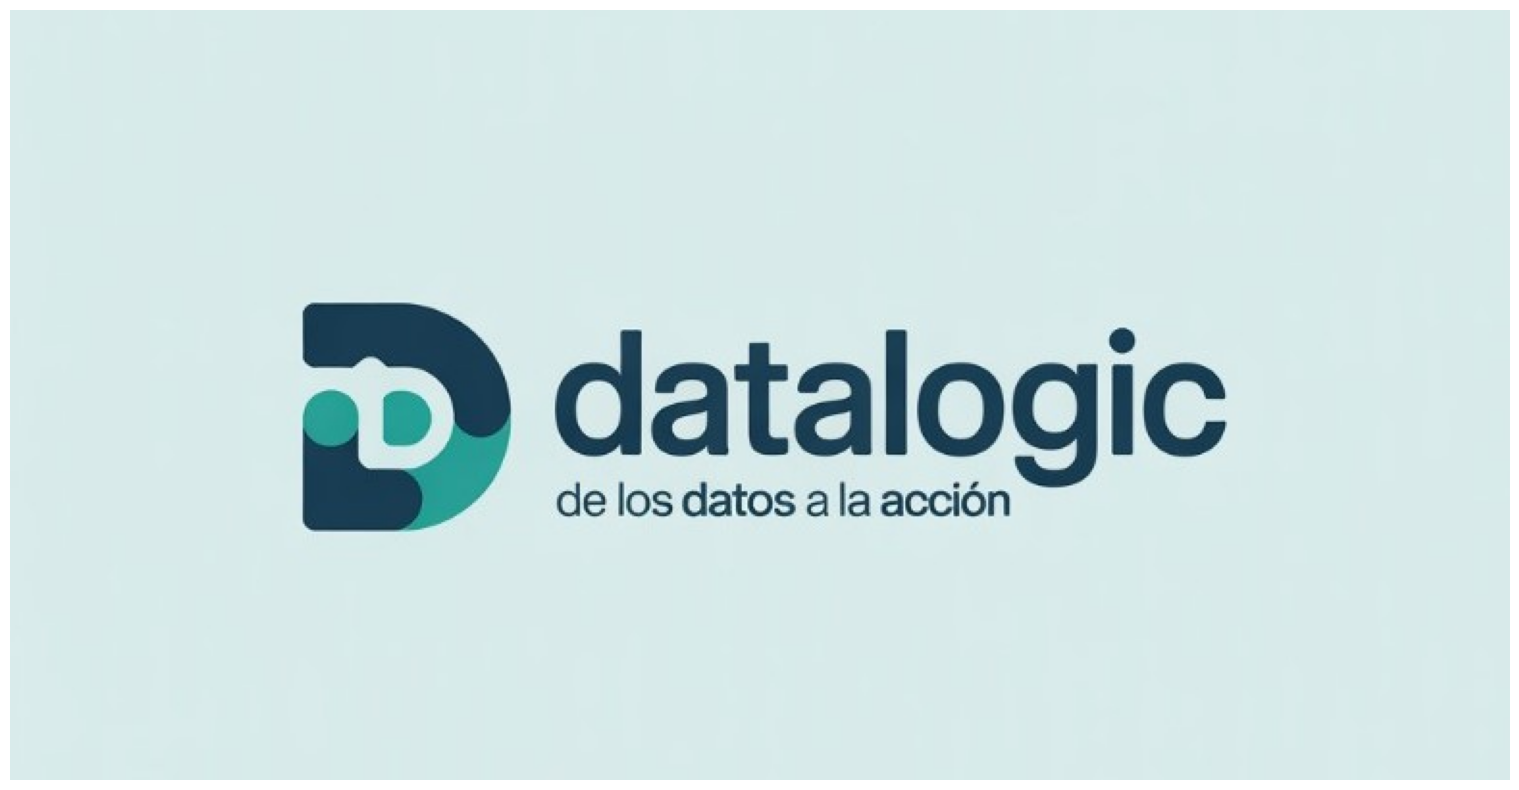

In [2]:
r.Imagen('../assets/consultora_logo.jpeg', (20,10))

#### Para Google Colab

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

# Importaciones

In [1]:
import numpy as np
import pandas as pd
# import os # en el caso que se trabaje en el entorno de colab

# os.chdir('/content/drive/MyDrive/NoCountry_RiesgoCrediticio/recursos_y_notebooks') # en el caso de que se trabaje en google colab

%load_ext autoreload
%autoreload 2

import resources as r

# Este codigo Pone un limite grande para el ancho y sin limite para el largo de un output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.width', 1000)

In [5]:
# lista_produccion = os.listdir('../raw/')

# <h1 align= 'center'><u><strong></strong>Datos</u></h1>

Detallamos los ficheros y sus origenes principales:

* churn: https://www.kaggle.com/datasets/barelydedicated/bank-customer-churn-modeling
* Churn_v2: https://zomalex.co.uk/datasets/bank_churn_dataset.html?utm_source=chatgpt.com
* churn_data: https://github.com/marco11235813/Retencion-de-clientes---NoCountry/blob/main/data/1.5%20synthetic/churn_data.csv, (Datos sinteticos generados).


En este informe se detalla el estado de la calidad de los datos de manera general, como paso previo a realizar un ETL de los mismos.

### Instanciamos los dataframes

In [ ]:
churn = pd.read_csv('../data/1. raw/churn.csv')

In [ ]:
churn1 = pd.read_csv('../data/1. raw/Churn_v2.csv')

In [3]:
churn_data = pd.read_csv('../data/1.5 synthetic/churn_data.csv')

# <h1 align= 'center'><u><strong></strong>Análisis</u></h1>

## Churn

### Informe general

In [18]:
churn.head(7)

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,18,F,XW0DQ7H,Village,Platinum Membership,17-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,16:08:02,17,300.63,53005.25,17,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,32,F,5K0N3X1,City,Premium Membership,28-08-2017,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,16,306.34,12838.38,10,NaN,Yes,No,Yes,Solved,Quality Customer Care,0
2,44,F,1F2TCL3,Town,No Membership,11-11-2016,Yes,CID12313,Gift Vouchers/Coupons,Desktop,Wi-Fi,22:53:21,14,516.16,21027.00,22,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1
3,37,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,Gift Vouchers/Coupons,Desktop,Mobile_Data,15:57:50,11,53.27,25239.56,6,567.66,No,Yes,Yes,Unsolved,Poor Website,1
4,31,F,SVZXCWB,City,No Membership,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Mobile_Data,15:46:44,20,113.13,24483.66,16,663.06,No,Yes,Yes,Solved,Poor Website,1
5,13,M,PSG1LGF,City,Gold Membership,08-01-2016,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,6:46:07,23,433.62,13884.77,24,722.27,Yes,No,Yes,Unsolved,No reason specified,0
6,21,M,R3CX1EA,Town,Gold Membership,19-03-2015,Yes,CID24708,Gift Vouchers/Coupons,Desktop,Mobile_Data,11:40:04,10,55.38,8982.50,28,756.21,Yes,No,Yes,Solved in Follow-up,No reason specified,0


* Agregar al diccionario de datos etiquetas y/o rango de valores correspondientes a cada campo.

In [8]:
r.informe_dataframe(churn)

INFORME PRELIMINAR SOBRE CARACTERISTICAS DEL DATASET:

--Dimensiones del DataFrame--
Filas: 36992
Columnas: 23

--Numero de datos--
841657

--Filas y Columnas--
Filas: muestra de indices-------> [0, 1, 2, 3, 4]  -----> Desde 0  Hasta 36991
Columnas: ['age', 'gender', 'security_no', 'region_category', 'membership_category', 'joining_date', 'joined_through_referral', 'referral_id', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'last_visit_time', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'feedback', 'churn_risk_score']

--Tipo de columnas--
age                               int64
gender                           object
security_no                      object
region_category                  object
membership_category              object
joining_date                     object
joined_through_referral   

'~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~oo~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~'

In [9]:
r.verificar_tipo_datos(churn)

,nombre_campo,tipo_datos,no_nulos_%,nulos_%,nulos
0,age,[<class 'int'>],100.00,0.00,0
1,gender,[<class 'str'>],100.00,0.00,0
2,security_no,[<class 'str'>],100.00,0.00,0
3,region_category,"[<class 'str'>, <class 'float'>]",85.33,14.67,5428
4,membership_category,[<class 'str'>],100.00,0.00,0
5,joining_date,[<class 'str'>],100.00,0.00,0
6,joined_through_referral,[<class 'str'>],100.00,0.00,0
7,referral_id,[<class 'str'>],100.00,0.00,0
8,preferred_offer_types,"[<class 'str'>, <class 'float'>]",99.22,0.78,288
9,medium_of_operation,[<class 'str'>],100.00,0.00,0


* existen valores nan en los campos region_category, preferred_offer_types, y points_in_wallet


### Informe particular

In [10]:
for columna in churn:
  r.informe_columna(churn, columna)

INFORME PRELIMINAR SOBRE LA COLUMNA/FEATURE age:

--Numero de datos nulos--
0

--Valores unicos en la columna--
Ej: [18 32 44 37 31]  -----> Desde 18  Hasta 63

--Estadisticos Principales de la columna--
Media: 37.12
Desviacion Estandar: 15.87
Primer cuartil: 23.0
Mediana: 37.0
Tercer cuartil: 51.0

--Valores extremos--
Valor maximo: 64
Valor minimo: 10

--Distribucion de frecuencias (primeros valores con mayor cantidad de frecuencias)--
 33    720
42    716
16    716
Name: age, dtype: int64

--Valor maximo y minimo--
Maximo: 64
Minimo: 10

------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------
INFORME PRELIMINAR SOBRE LA COLUMNA/FEATURE gender:

--Numero de datos nulos--
0

--Cantidad de valores unicos en la columna--
3

--Valores unicos en la columna--
['F' 'M' 'Unknown']

--Moda de la columna especi

* existen valores incongruentes y/o ilogicos en el campo 'days_since_last_login'
* existen valores incongruentes y/o ilogicos en el campo 'avg_time_spent'
* el valor 'error' que se presenta en el campo 'avg_frequency_login_days' debe ser formateado o en todo caso, se le debe dar un analisis pormenorizado del valor de referencia la cual apunta en el contexto del campo
* revisar valores negativos en el campo 'points_in_wallet'
* deliverar sobre el valor de etiqueta 'not applicable' en el campo 'complaint_status'
* el campo 'churn_risk_score' habilita como uso de target para potenciales desarrollos de modelos de clasificacion???



### Gráficos

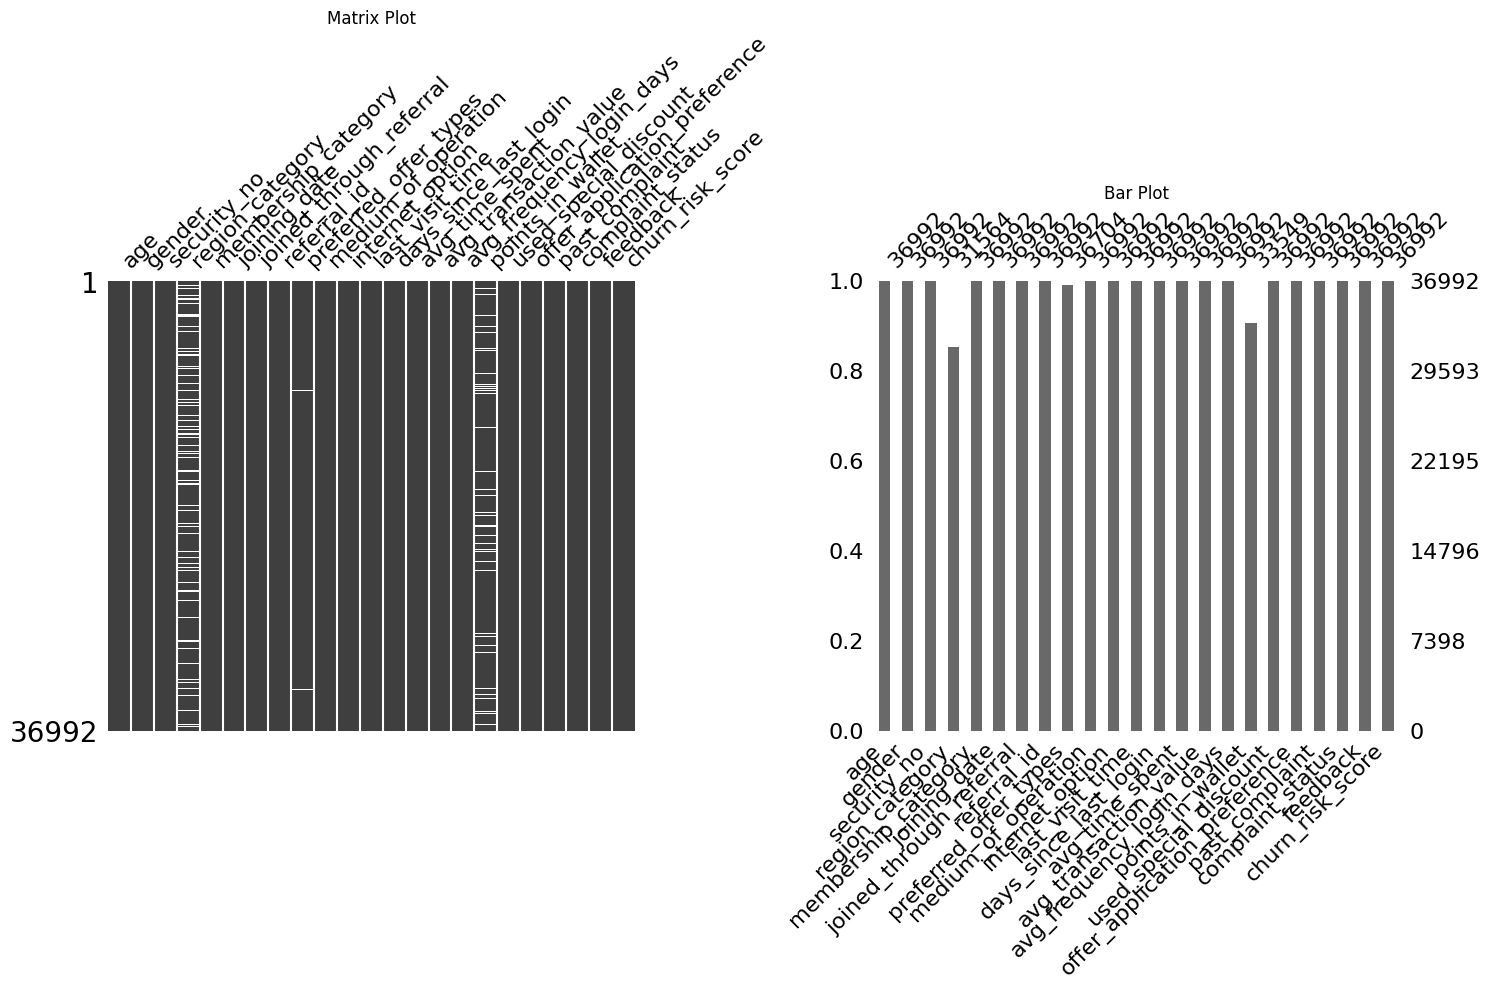

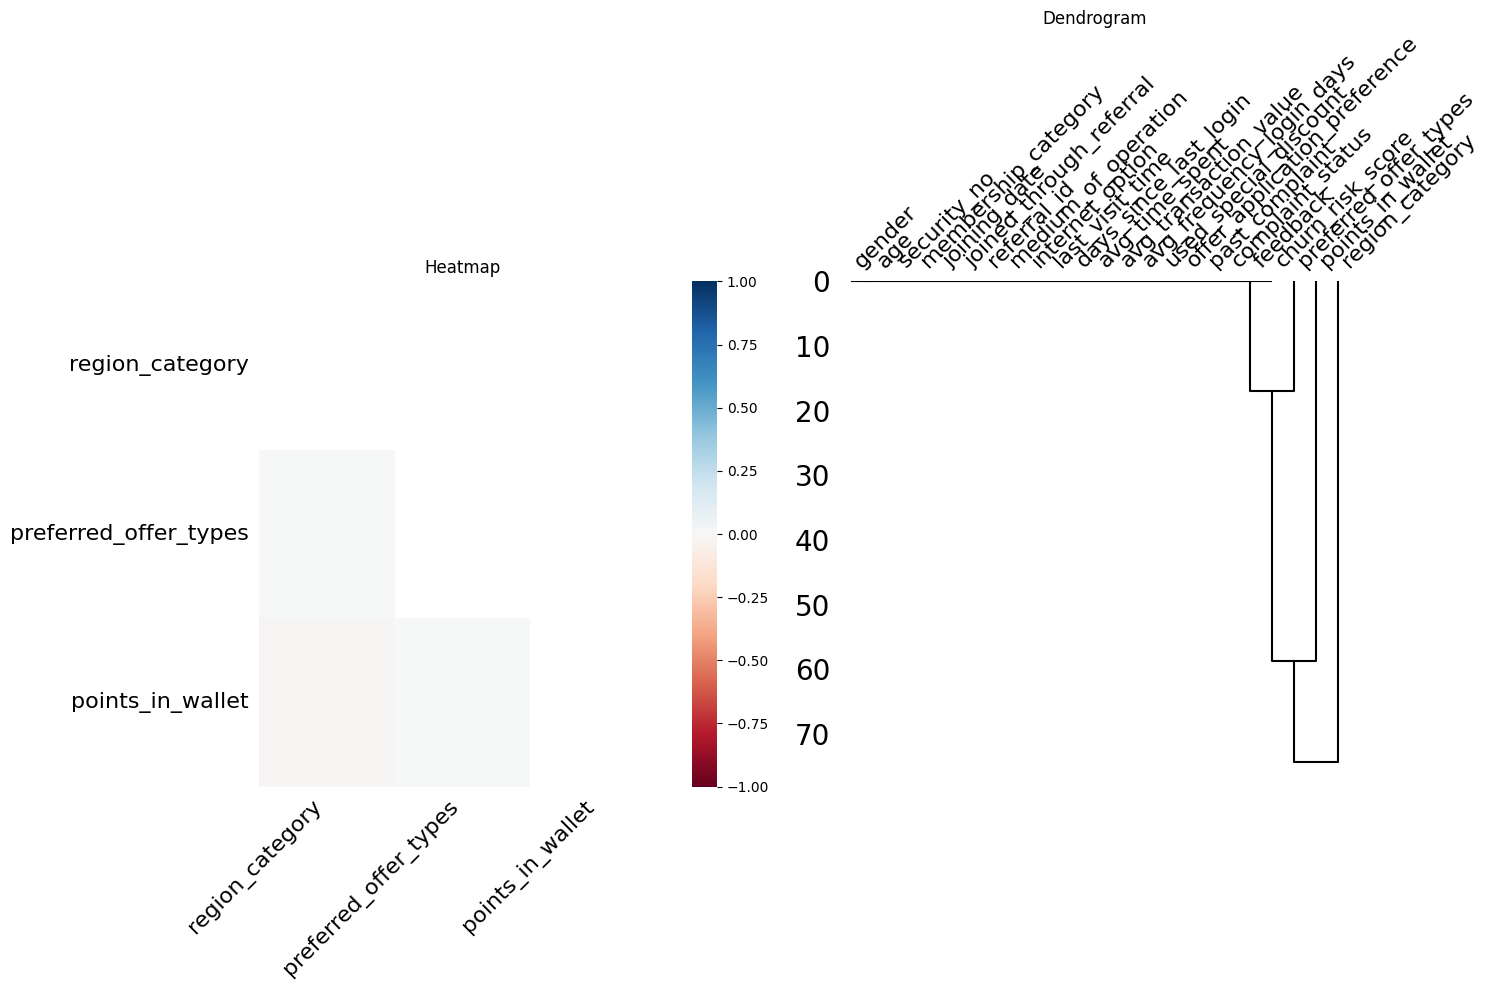

In [11]:
r.visualizar_nulos(churn)

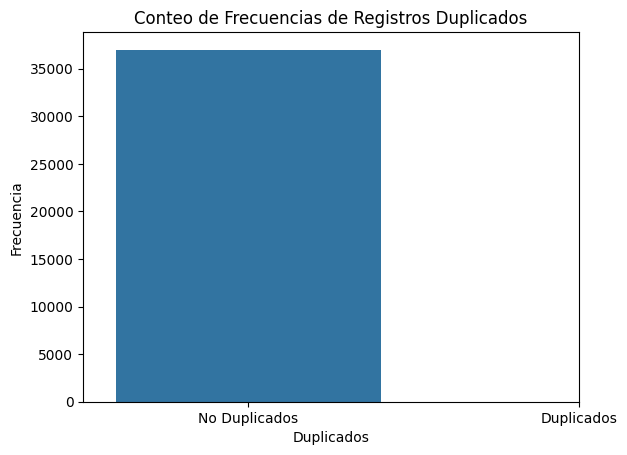

In [12]:
r.hist_duplicados(churn)

* No se identifican por el momento registros duplicados

## Churn1

In [19]:
churn1.head(7)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0


* Consultar por el valor de la informacion de este dataframe en el desarrollo del proyecto
* agregar a diccionario de datos la estructura de significados de cada campo como asi tambien señalar el tipo de dato y las referencias de valores de etiquetas o rangos de los mismos.
* campo RowNumber no tiene sentido de existencia, ya que es un campo de asignacion de valor de row()registro/fila, lo que redunda con la existencia del index.
* identificar campos analogos con los campos de otros dataframes, en caso de haberlos, realizar la normalizacion de datos en su conjunto como asi tambien la modificacion de etiquetas de columna.


### Informe general

In [13]:
r.informe_dataframe(churn1)

INFORME PRELIMINAR SOBRE CARACTERISTICAS DEL DATASET:

--Dimensiones del DataFrame--
Filas: 10000
Columnas: 14

--Numero de datos--
140000

--Filas y Columnas--
Filas: muestra de indices-------> [0, 1, 2, 3, 4]  -----> Desde 0  Hasta 9999
Columnas: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

--Tipo de columnas--
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object
--Cantidad de registros duplicados--
0



'~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~oo~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~'

In [14]:
r.verificar_tipo_datos(churn1)

,nombre_campo,tipo_datos,no_nulos_%,nulos_%,nulos
0,RowNumber,[<class 'int'>],100.0,0.0,0
1,CustomerId,[<class 'int'>],100.0,0.0,0
2,Surname,[<class 'str'>],100.0,0.0,0
3,CreditScore,[<class 'int'>],100.0,0.0,0
4,Geography,[<class 'str'>],100.0,0.0,0
5,Gender,[<class 'str'>],100.0,0.0,0
6,Age,[<class 'int'>],100.0,0.0,0
7,Tenure,[<class 'int'>],100.0,0.0,0
8,Balance,[<class 'float'>],100.0,0.0,0
9,NumOfProducts,[<class 'int'>],100.0,0.0,0


* el dataframe no presenta datos nan en ninguno de sus campos

### Informe particular

In [15]:
for columna in churn1:
  r.informe_columna(churn1, columna)

INFORME PRELIMINAR SOBRE LA COLUMNA/FEATURE RowNumber:

--Numero de datos nulos--
0

--Valores unicos en la columna--
Ej: [1 2 3 4 5]  -----> Desde 1  Hasta 10000

--Estadisticos Principales de la columna--
Media: 5000.5
Desviacion Estandar: 2886.9
Primer cuartil: 2500.75
Mediana: 5000.5
Tercer cuartil: 7500.25

--Valores extremos--
Valor maximo: 10000
Valor minimo: 1

--Distribucion de frecuencias (primeros valores con mayor cantidad de frecuencias)--
 1       1
6671    1
6664    1
Name: RowNumber, dtype: int64

--Valor maximo y minimo--
Maximo: 10000
Minimo: 1

------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------
INFORME PRELIMINAR SOBRE LA COLUMNA/FEATURE CustomerId:

--Numero de datos nulos--
0

--Valores unicos en la columna--
Ej: [15634602 15647311 15619304 15701354 15737888]  -----> Desde 1563

* campo CreditScore, analizar sus valores y la informacion que contienen y a la cual hacen referencia
* campo, Geography contiene los valores de 'France', 'Germany' y 'Spain', lo que hacen referencia a esos paises. Esto puede llegar a presentar un conflicto con los datos de otros dataframes, ya que puede tornarse incongruente o sesgada la utilizacion de ambos dataframes con referencias de diferentes paises/continentes/regiones, consultar con el equipo
* Formatear valores de la columna Gender
* discutir el valor .0, su cantidad y su significado presente en el campo Balance



### Gráficos

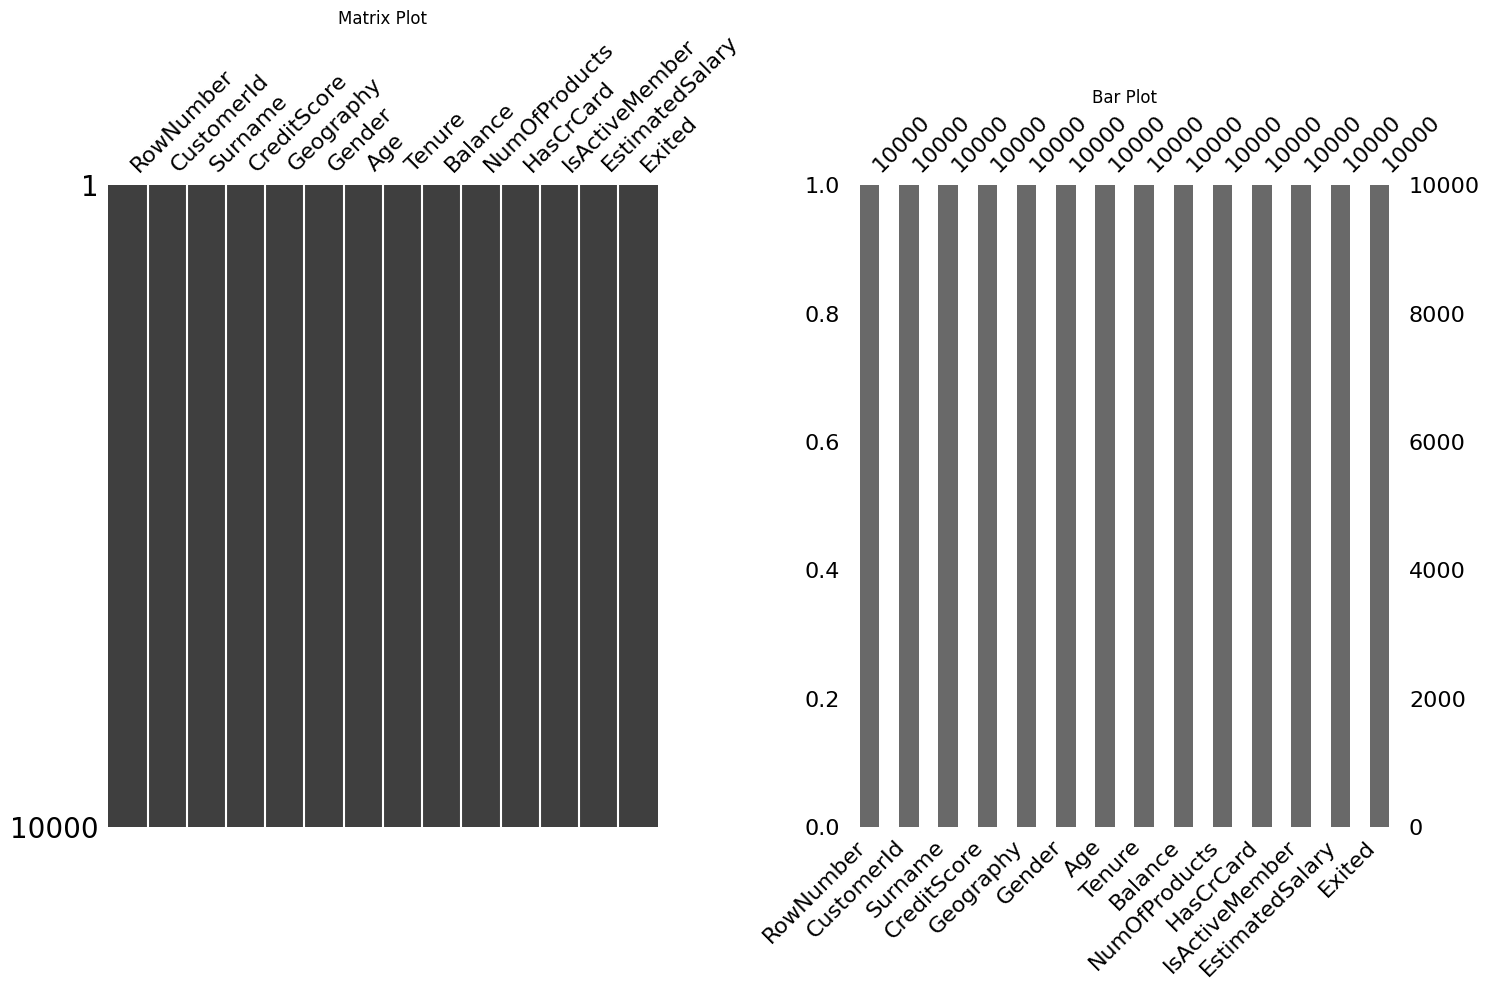

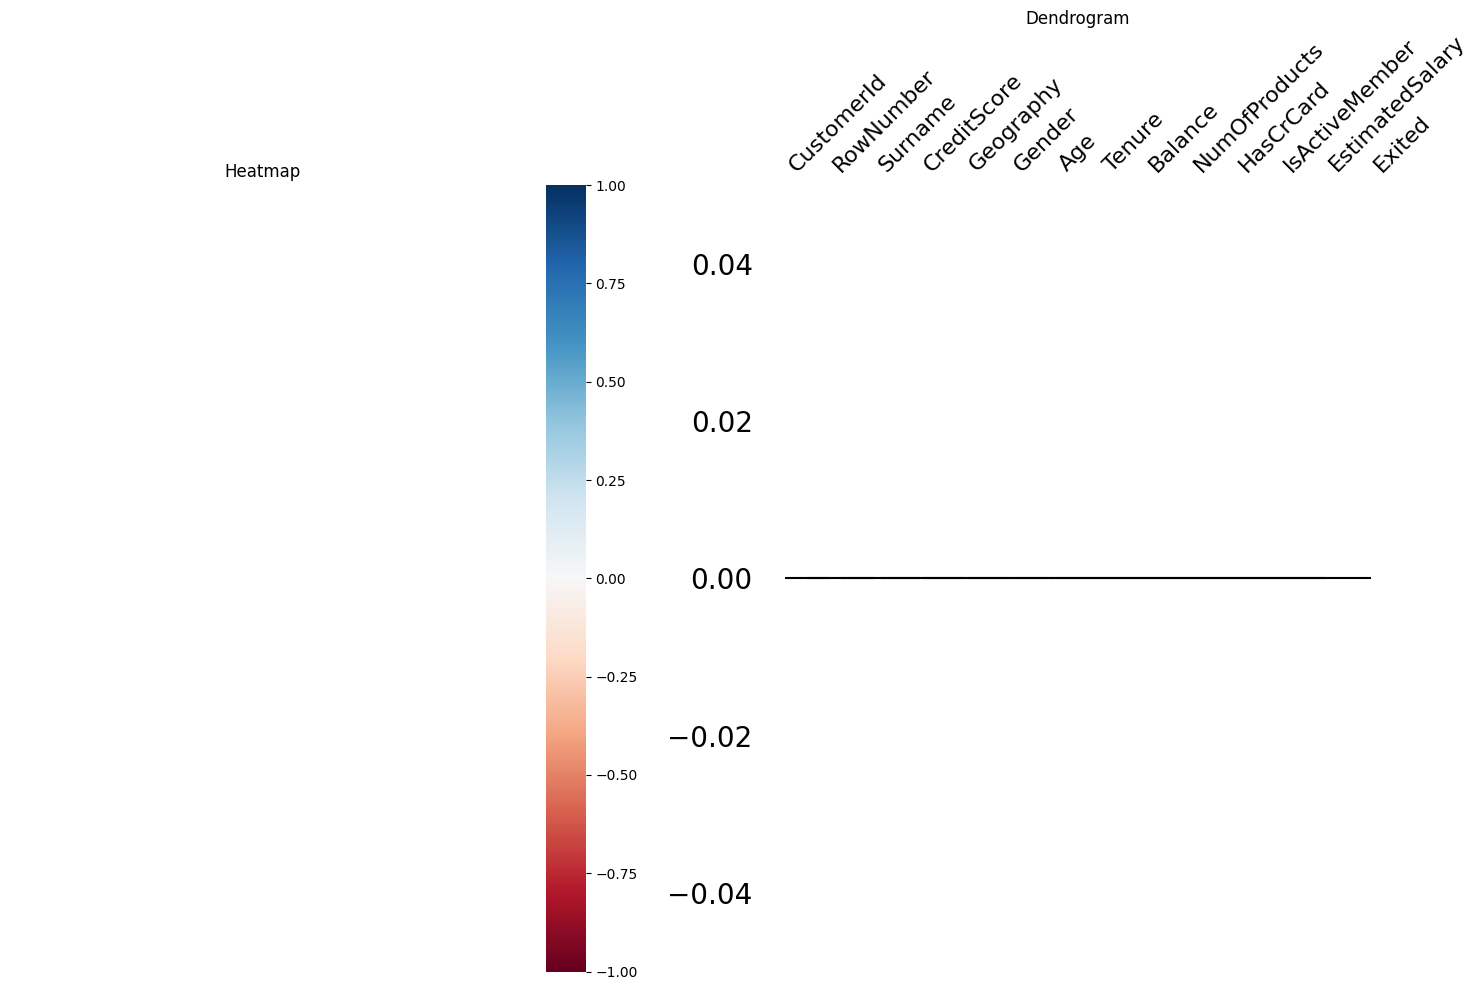

In [16]:
r.visualizar_nulos(churn1)

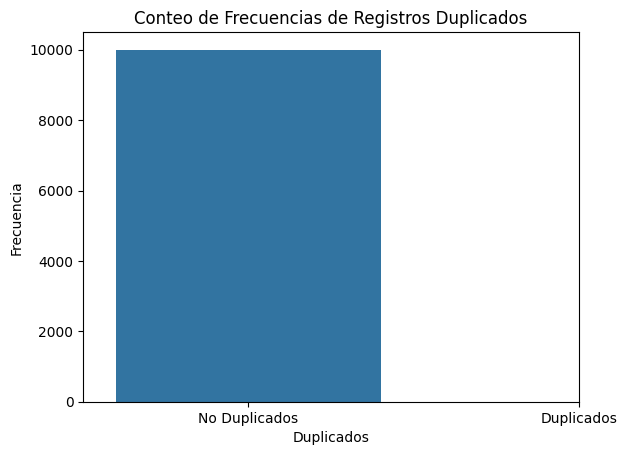

In [17]:
r.hist_duplicados(churn1)

## Churn_data

In [5]:
churn_data.head(7)

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score,nps_score,tx_count_30d,avg_tx_amount,failed_tx,support_tickets
0,18,F,XW0DQ7H,Village,Platinum Membership,17-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,16:08:02,320,300.63,53005.25,17,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0,4,74,908.82,45,0
1,32,F,5K0N3X1,City,Premium Membership,28-08-2017,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,18,306.34,12838.38,10,NaN,Yes,No,Yes,Solved,Quality Customer Care,0,3,73,536.62,33,5
2,44,F,1F2TCL3,Town,No Membership,11-11-2016,Yes,CID12313,Gift Vouchers/Coupons,Desktop,Wi-Fi,22:53:21,102,516.16,21027.00,22,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1,4,27,668.29,12,2
3,37,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,Gift Vouchers/Coupons,Desktop,Mobile_Data,15:57:50,193,53.27,25239.56,6,567.66,No,Yes,Yes,Unsolved,Poor Website,1,6,32,508.17,41,9
4,31,F,SVZXCWB,City,No Membership,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Mobile_Data,15:46:44,40,113.13,24483.66,16,663.06,No,Yes,Yes,Solved,Poor Website,1,6,18,27.63,41,3
5,13,M,PSG1LGF,City,Gold Membership,08-01-2016,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,6:46:07,119,433.62,13884.77,24,722.27,Yes,No,Yes,Unsolved,No reason specified,0,1,77,433.15,48,1
6,21,M,R3CX1EA,Town,Gold Membership,19-03-2015,Yes,CID24708,Gift Vouchers/Coupons,Desktop,Mobile_Data,11:40:04,261,55.38,8982.50,28,756.21,Yes,No,Yes,Solved in Follow-up,No reason specified,0,1,71,348.69,21,9


* Consultar por el valor de la informacion de este dataframe en el desarrollo del proyecto
* identificar campos analogos con los campos de otros dataframes, en caso de haberlos, realizar la normalizacion de datos en su conjunto como asi tambien la modificacion de etiquetas de columna.


### Informe general

In [6]:
r.informe_dataframe(churn_data)

INFORME PRELIMINAR SOBRE CARACTERISTICAS DEL DATASET:

--Dimensiones del DataFrame--
Filas: 36992
Columnas: 28

--Numero de datos--
1026617

--Filas y Columnas--
Filas: muestra de indices-------> [0, 1, 2, 3, 4]  -----> Desde 0  Hasta 36991
Columnas: ['age', 'gender', 'security_no', 'region_category', 'membership_category', 'joining_date', 'joined_through_referral', 'referral_id', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'last_visit_time', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'feedback', 'churn_risk_score', 'nps_score', 'tx_count_30d', 'avg_tx_amount', 'failed_tx', 'support_tickets']

--Tipo de columnas--
age                               int64
gender                           object
security_no                      object
region_category                  object
membership_category        

'~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~oo~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~'

In [7]:
r.verificar_tipo_datos(churn_data)

,nombre_campo,tipo_datos,no_nulos_%,nulos_%,nulos
0,age,[<class 'int'>],100.00,0.00,0
1,gender,[<class 'str'>],100.00,0.00,0
2,security_no,[<class 'str'>],100.00,0.00,0
3,region_category,"[<class 'str'>, <class 'float'>]",85.33,14.67,5428
4,membership_category,[<class 'str'>],100.00,0.00,0
5,joining_date,[<class 'str'>],100.00,0.00,0
6,joined_through_referral,[<class 'str'>],100.00,0.00,0
7,referral_id,[<class 'str'>],100.00,0.00,0
8,preferred_offer_types,"[<class 'str'>, <class 'float'>]",99.22,0.78,288
9,medium_of_operation,[<class 'str'>],100.00,0.00,0


* Campos region_category, preferred_offer_types y points_in_wallet presentan datos nan que hay que tratar
* Campos joining_date y last_visit_time son campos con datos string, por lo que hay que realizar la correcta asignacion de tipo de dato para sus datos a datetime

### Informe particular

In [8]:
for columna in churn_data:
  r.informe_columna(churn_data,columna)

INFORME PRELIMINAR SOBRE LA COLUMNA/FEATURE age:

--Numero de datos nulos--
0

--Valores unicos en la columna--
Ej: [18 32 44 37 31]  -----> Desde 18  Hasta 63

--Estadisticos Principales de la columna--
Media: 37.12
Desviacion Estandar: 15.87
Primer cuartil: 23.0
Mediana: 37.0
Tercer cuartil: 51.0

--Valores extremos--
Valor maximo: 64
Valor minimo: 10

--Distribucion de frecuencias (primeros valores con mayor cantidad de frecuencias)--
 33    720
42    716
16    716
Name: age, dtype: int64

--Valor maximo y minimo--
Maximo: 64
Minimo: 10

------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------
INFORME PRELIMINAR SOBRE LA COLUMNA/FEATURE gender:

--Numero de datos nulos--
0

--Cantidad de valores unicos en la columna--
3

--Valores unicos en la columna--
['F' 'M' 'Unknown']

--Moda de la columna especi

* campo CreditScore, analizar sus valores y la informacion que contienen y a la cual hacen referencia
* campo, Geography contiene los valores de 'France', 'Germany' y 'Spain', lo que hacen referencia a esos paises. Esto puede llegar a presentar un conflicto con los datos de otros dataframes, ya que puede tornarse incongruente o sesgada la utilizacion de ambos dataframes con referencias de diferentes paises/continentes/regiones, consultar con el equipo
* Formatear valores de la columna Gender
* discutir el valor .0, su cantidad y su significado presente en el campo Balance



### Gráficos

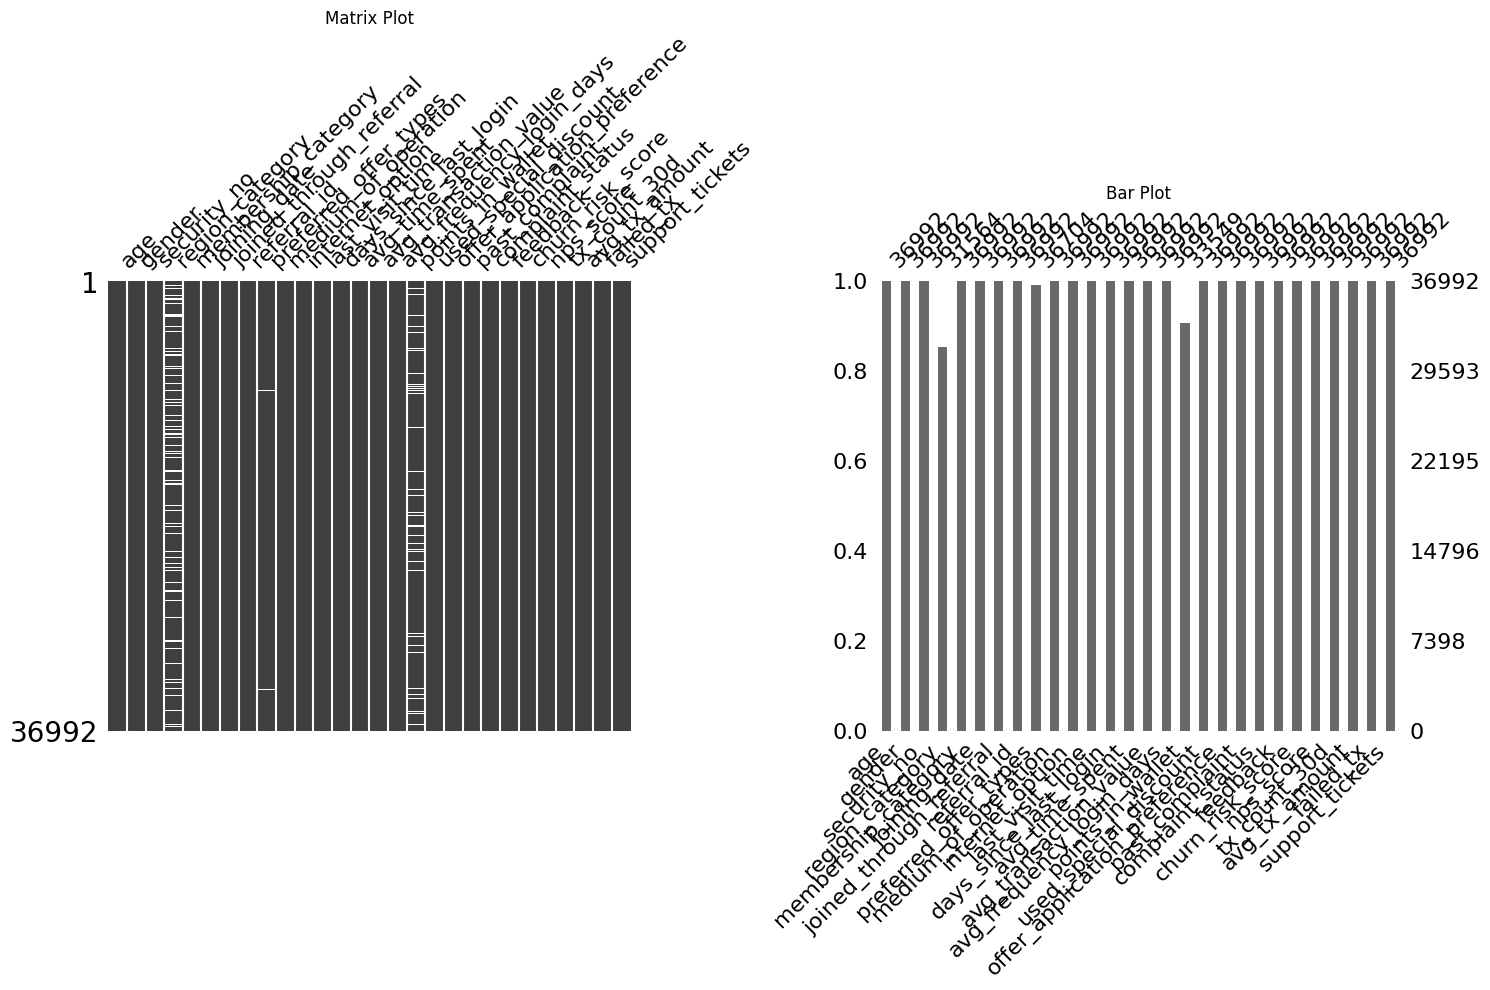

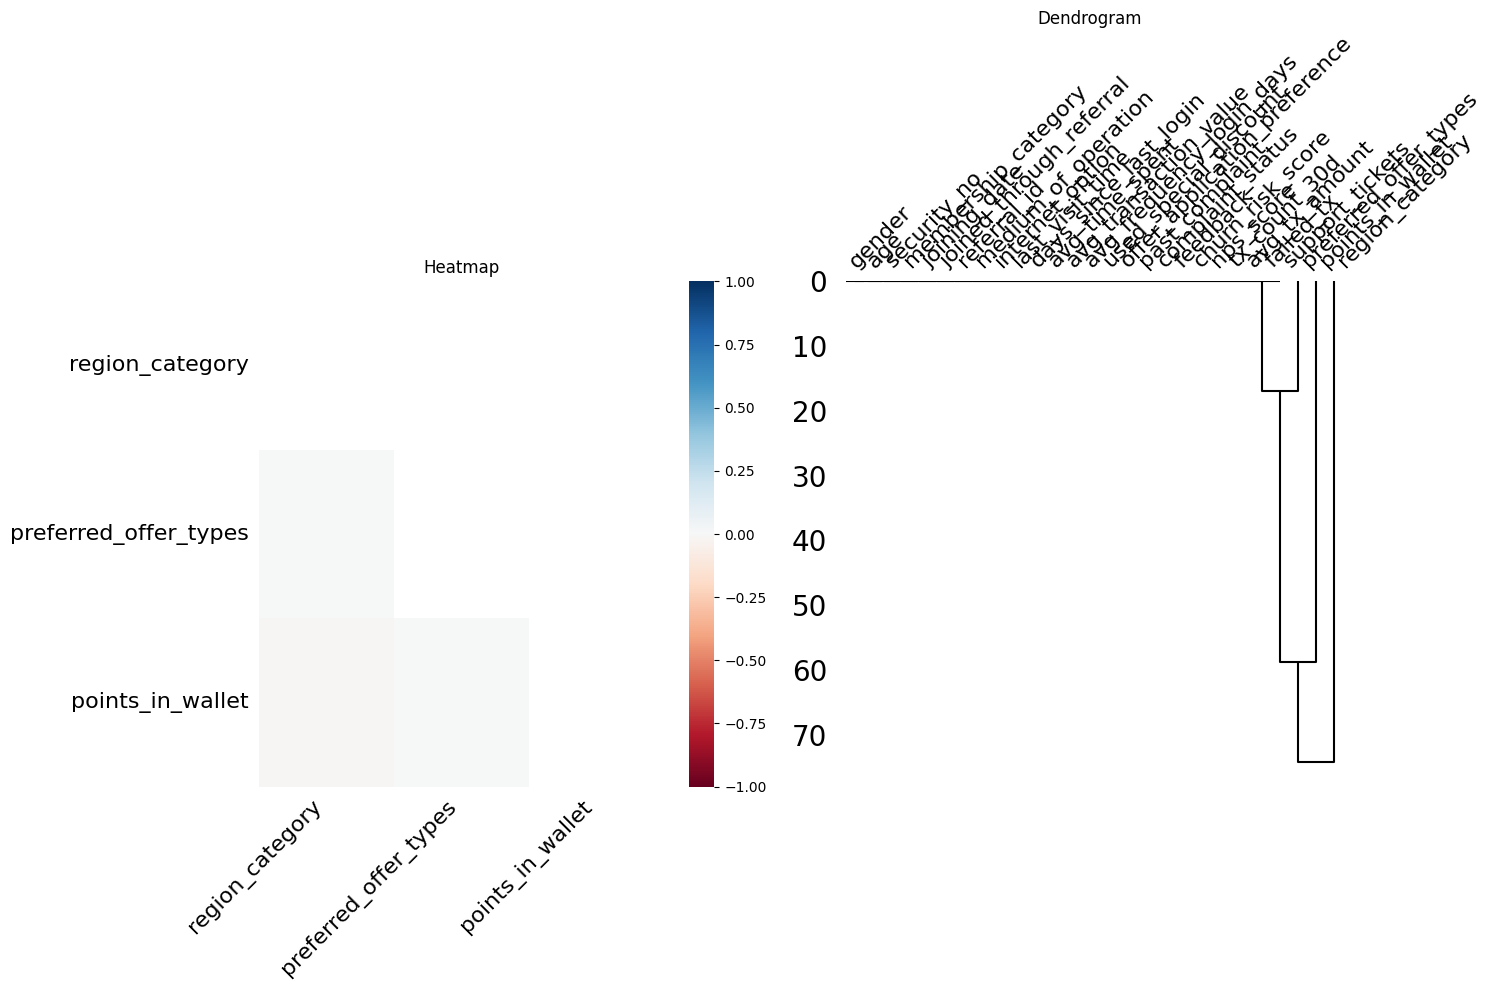

In [9]:
r.visualizar_nulos(churn_data)

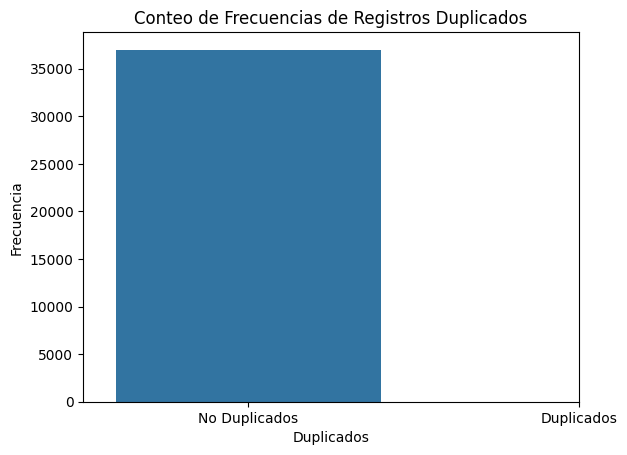

In [10]:
r.hist_duplicados(churn_data)

* Por el momento no se registran registros duplicados

# <h1 align= 'center'><u><strong></strong>Conclusiones</u></h1>

Diccionario de Datos: https://docs.google.com/spreadsheets/d/1Ifawd985eE5mp87ZMlTS6lJ_GMi6HmylaiANZKAMYfM/edit?usp=sharing

...................
........................

Siempre teniendo en cuenta la inclusion de mas datos nuevos de los mismos o de diferentes origenes, que puedan utilizarse y ser pertinentes al desarrollo del producto/proyecto